<a href="https://colab.research.google.com/github/G-Deekshita/BEE-102-Spring-2025-Assignment/blob/main/BEE_Qn_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Statement**


**Fragment length frequency**

You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Normalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

query.bed.gz

**Rescaling**

Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

reference.hist

# **Approach**

# **1. Fragment Length Extraction**

We begin by reading the query.bed.gz file, which contains genomic fragment mapping information. Each line in the BED file includes:

Start position (column 2): The starting genomic coordinate of a fragment.

End position (column 3): The ending coordinate of the fragment.

The fragment length is computed as:

                Fragment Length = End Position - Start Position
These lengths are extracted and stored as a pandas.Series for efficient statistical analysis and plotting.

# **2. Frequency Counting and Normalization**
Once we have the list of fragment lengths:

We count the frequency of each unique fragment length using value_counts(), which returns a dictionary-like structure indexed by length.

The raw frequencies are normalized by dividing each count by the total number of fragments. This converts the distribution into a probability distribution where:

Sum of all normalized frequencies = 1

This normalized query distribution represents the empirical fragment size profile of the input sample.

# **3. Reference Distribution Import**
To align the sample to a known profile, we load the reference distribution from reference.hist. Each line in this file contains:

Fragment length (in base pairs)

Normalized frequency (i.e., relative proportion of this fragment length in the reference)

The file is read using pandas.read_csv() and stored in a Series indexed by fragment length. This allows for easy lookup of expected frequencies during resampling.

# **4. Rescaling (Subsampling to Match Reference)**
To make the query dataset mimic the reference distribution, we subsample the original fragment pool.

Steps involved:

Determine target sample size: Set to 30% of the original query fragment count.

Group original fragments by length: This allows us to efficiently sample only from available fragments of a given length.

For each fragment length in the reference:

Compute the desired number of samples based on the reference fraction and the target sample size.

Randomly sample the required number of fragments from the corresponding pool in the original dataset.

If fewer fragments are available than required, sample all available.

The result is a new fragment pool with a distribution shaped to match the reference as closely as possible.

# **5. Visualization**
Three separate fragment length distributions are plotted on the same graph for visual comparison:

Query (Sample) Distribution: The original normalized fragment length distribution from query.bed.gz.

Reference Distribution: The desired target profile provided in reference.hist.

Resampled Distribution: The new distribution obtained after subsampling the query data.

Plot features:

The X-axis shows fragment lengths (in bp).

The Y-axis shows normalized frequency.



In [ ]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gzip
from collections import defaultdict
import random

In [ ]:
# Function to read fragment lengths from a gzipped BED file
def read_bed_fragments(bed_file_path):
    fragment_lengths = []
    with gzip.open(bed_file_path, 'rt') as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                fields = line.strip().split('\t')
                if len(fields) >= 3:
                    start_pos = int(fields[1])
                    end_pos = int(fields[2])
                    length = end_pos - start_pos
                    fragment_lengths.append(length)
    return pd.Series(fragment_lengths, name='lengths')

# Load the query BED file
query_fragments = read_bed_fragments('query.bed.gz')

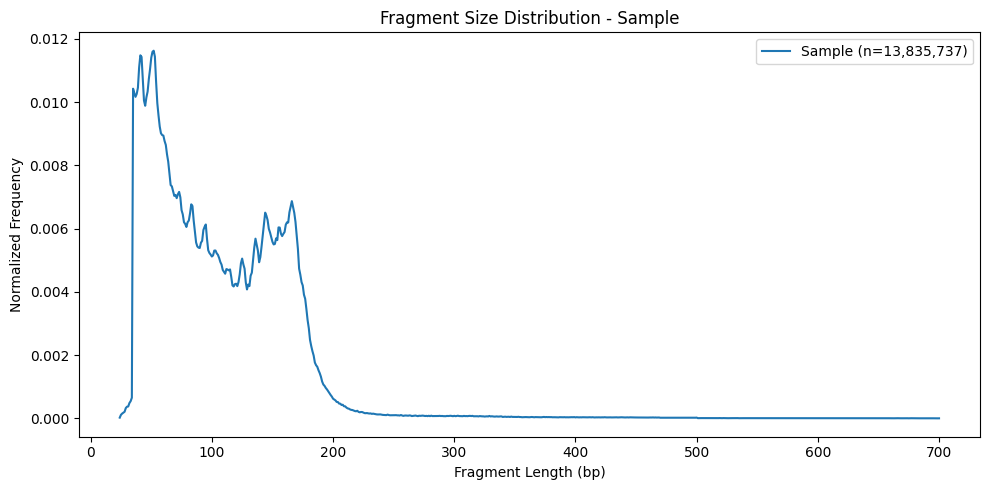

In [ ]:
# Frequency distribution of fragment lengths
frag_freqs = query_fragments.value_counts().sort_index()
norm_query_distribution = frag_freqs / frag_freqs.sum()

# Visualization of the original query distribution
plt.figure(figsize=(10, 5))
plt.plot(norm_query_distribution.index, norm_query_distribution.values, label=f'Sample (n={len(query_fragments):,})')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Fragment Size Distribution - Sample")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Function to read reference distribution from file
def read_reference_histogram(hist_path):
    df = pd.read_csv(hist_path, sep='\t', header=None, names=['len', 'freq'])
    df['len'] = df['len'].astype(int)
    return df.set_index('len')['freq'].sort_index()

# Load the reference histogram
ref_distribution = read_reference_histogram('reference.hist')

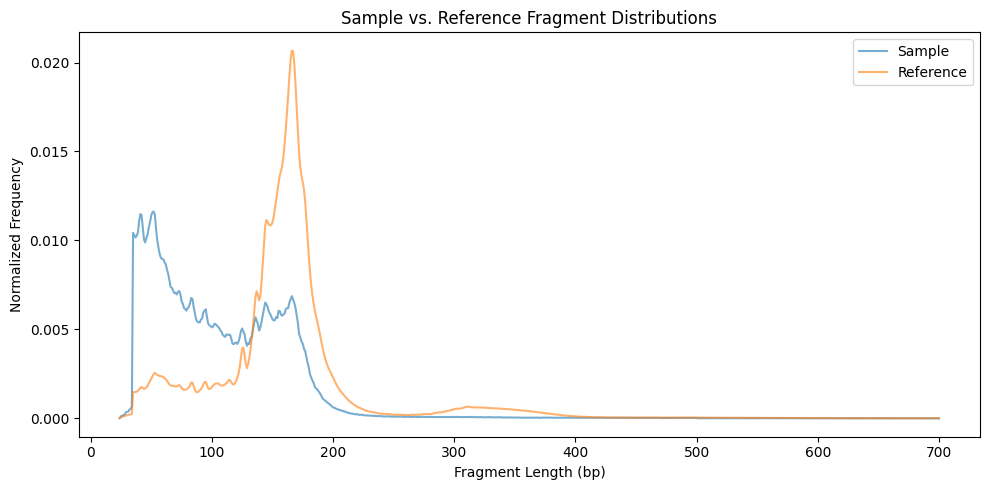

In [ ]:
# Plot both distributions together
plt.figure(figsize=(10, 5))
plt.plot(norm_query_distribution.index, norm_query_distribution.values, label='Sample', alpha=0.6)
plt.plot(ref_distribution.index, ref_distribution.values, label='Reference', alpha=0.6)
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Sample vs. Reference Fragment Distributions")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Group fragment lengths for controlled sampling
length_group_map = defaultdict(list)
for frag_len in query_fragments:
    length_group_map[frag_len].append(frag_len)

# Desired sample size (30% of original)
resample_target = int(len(query_fragments) * 0.3)
resampled_fragments = []

# Generate rescaled fragment pool matching reference profile
for frag_len, ref_fraction in ref_distribution.items():
    if frag_len in length_group_map:
        available = length_group_map[frag_len]
        sample_count = int(ref_fraction * resample_target)
        chosen = random.sample(available, min(sample_count, len(available)))
        resampled_fragments.extend(chosen)

# Convert to Series and normalize
resampled_series = pd.Series(resampled_fragments)
resampled_counts = resampled_series.value_counts().sort_index()
norm_resampled_distribution = resampled_counts / resampled_counts.sum()


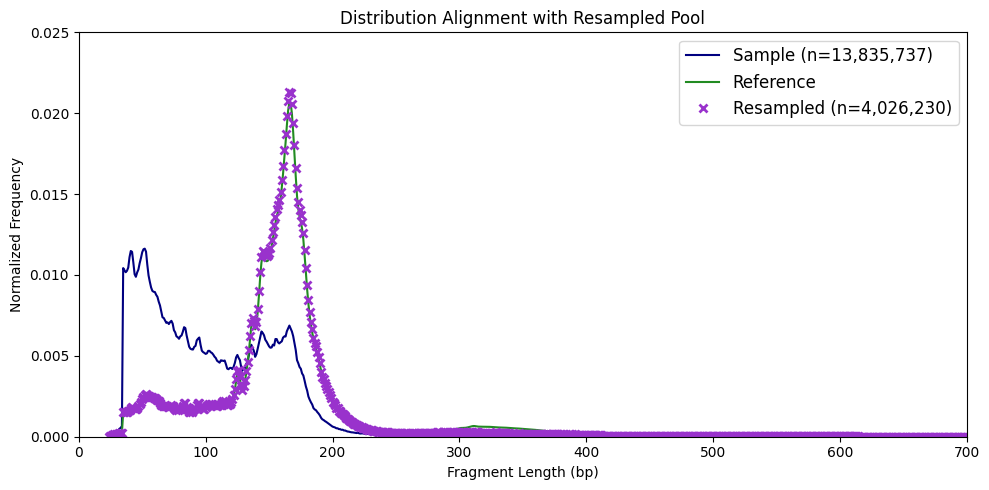

In [ ]:
# Final plot of all three distributions
plt.figure(figsize=(10, 5))
plt.plot(norm_query_distribution.index, norm_query_distribution.values, label=f'Sample (n={len(query_fragments):,})', color='navy')
plt.plot(ref_distribution.index, ref_distribution.values, label='Reference', color='forestgreen')
plt.plot(norm_resampled_distribution.index, norm_resampled_distribution.values, 'x', label=f'Resampled (n={len(resampled_fragments):,})',
         color='darkorchid', markersize=6, markeredgewidth=2)

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.title("Distribution Alignment with Resampled Pool")
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("fragment_distribution_rescaled.png")
plt.show()